# CFP_Conformal_Calibration

Calibration-efficiency frontier: raw vs corrected coverage and VaR width for representative models.

**Output:** `fig_frontier_killer.pdf`  
**Paper:** Pele, Bolovaneanu, Ginavar, Lessmann, Härdle (2026)  
**Q** [Conformal_Oracle](https://github.com/QuantLet/Conformal_Oracle/)

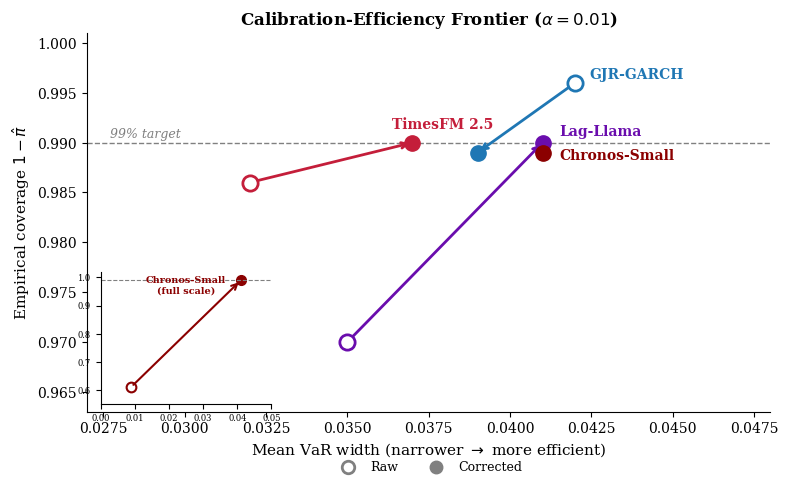

Saved fig_frontier_killer


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import shutil

# ── Paths ──────────────────────────────────────────────────────────
FIG_DIR  = Path('../cfp_ijf_data/paper_outputs/figures')
ROOT_FIG = Path('../../figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)
ROOT_FIG.mkdir(parents=True, exist_ok=True)

# ── Style ─────────────────────────────────────────────
plt.rcParams.update({
    'font.family':'serif', 'axes.grid':False,
    'savefig.transparent':True, 'savefig.dpi':300,
    'axes.spines.top':False, 'axes.spines.right':False,
    'font.size':10,
})

# ── Data from Table 4 ─────────────────────────────────────────────
models = {
    'TimesFM 2.5': {
        'raw_width': 0.032, 'raw_cov': 1 - 0.014,
        'corr_width': 0.037, 'corr_cov': 1 - 0.010,
        'color': '#c41e3a',
    },
    'Lag-Llama': {
        'raw_width': 0.035, 'raw_cov': 1 - 0.030,
        'corr_width': 0.041, 'corr_cov': 1 - 0.010,
        'color': '#6a0dad',
    },
    'GJR-GARCH': {
        'raw_width': 0.042, 'raw_cov': 1 - 0.004,
        'corr_width': 0.039, 'corr_cov': 1 - 0.011,
        'color': '#1f77b4',
    },
    'Chronos-Small': {
        'raw_width': 0.009, 'raw_cov': 1 - 0.388,
        'corr_width': 0.041, 'corr_cov': 1 - 0.011,
        'color': '#8b0000',
    },
}

fig, ax = plt.subplots(figsize=(8, 5))

# Main plot
for name, d in models.items():
    if name == 'Chronos-Small':
        ax.plot(d['corr_width'], d['corr_cov'], 'o',
                color=d['color'], ms=11, zorder=5)
        ax.annotate(name, (d['corr_width'], d['corr_cov']),
                    xytext=(12, -5), textcoords='offset points',
                    fontsize=10, fontweight='bold', color=d['color'])
    else:
        ax.plot(d['raw_width'], d['raw_cov'], 'o',
                mfc='white', mec=d['color'], ms=11, mew=2, zorder=5)
        ax.plot(d['corr_width'], d['corr_cov'], 'o',
                color=d['color'], ms=11, zorder=5)
        ax.annotate('', xy=(d['corr_width'], d['corr_cov']),
                    xytext=(d['raw_width'], d['raw_cov']),
                    arrowprops=dict(arrowstyle='->', lw=2, color=d['color']))

# Labels
ax.annotate('TimesFM 2.5',
            (models['TimesFM 2.5']['corr_width'],
             models['TimesFM 2.5']['corr_cov']),
            xytext=(-15, 10), textcoords='offset points',
            fontsize=10, fontweight='bold',
            color=models['TimesFM 2.5']['color'])
ax.annotate('Lag-Llama',
            (models['Lag-Llama']['corr_width'],
             models['Lag-Llama']['corr_cov']),
            xytext=(12, 5), textcoords='offset points',
            fontsize=10, fontweight='bold',
            color=models['Lag-Llama']['color'])
ax.annotate('GJR-GARCH',
            (models['GJR-GARCH']['raw_width'],
             models['GJR-GARCH']['raw_cov']),
            xytext=(10, 3), textcoords='offset points',
            fontsize=10, fontweight='bold',
            color=models['GJR-GARCH']['color'])

ax.set_title('Calibration-Efficiency Frontier ($\\alpha = 0.01$)',
             fontsize=12, fontweight='bold')
ax.axhline(y=0.99, color='grey', ls='--', lw=1, zorder=1)
ax.text(0.0277, 0.9905, '99% target', fontsize=9, color='grey', style='italic')
ax.set_xlabel(r'Mean VaR width (narrower $\rightarrow$ more efficient)', fontsize=11)
ax.set_ylabel(r'Empirical coverage $1 - \hat{\pi}$', fontsize=11)
ax.set_xlim(0.027, 0.048)
ax.set_ylim(0.963, 1.001)

hollow = plt.Line2D([0],[0], marker='o', color='grey', mfc='white', ms=9, mew=2, ls='')
filled = plt.Line2D([0],[0], marker='o', color='grey', ms=9, ls='')
ax.legend([hollow, filled], ['Raw', 'Corrected'],
          loc='upper center', bbox_to_anchor=(0.5, -0.1),
          ncol=2, fontsize=9, frameon=False)

# Inset: Chronos-Small full scale
axins = ax.inset_axes([0.02, 0.02, 0.25, 0.35])
d = models['Chronos-Small']
axins.plot(d['raw_width'], d['raw_cov'], 'o', mfc='white', mec=d['color'], ms=7, mew=1.5)
axins.plot(d['corr_width'], d['corr_cov'], 'o', color=d['color'], ms=7)
axins.annotate('', xy=(d['corr_width'], d['corr_cov']),
               xytext=(d['raw_width'], d['raw_cov']),
               arrowprops=dict(arrowstyle='->', lw=1.5, color=d['color']))
axins.axhline(y=0.99, color='grey', ls='--', lw=0.8)
axins.set_xlim(0.0, 0.05); axins.set_ylim(0.55, 1.02)
axins.text(0.5, 0.97, 'Chronos-Small\n(full scale)',
           transform=axins.transAxes, fontsize=7,
           color=d['color'], fontweight='bold', ha='center', va='top')
axins.tick_params(labelsize=6)
axins.spines['top'].set_visible(False)
axins.spines['right'].set_visible(False)

plt.tight_layout()
for ext in ['pdf','png']:
    fig.savefig(FIG_DIR / f'fig_frontier_killer.{ext}', dpi=300, bbox_inches='tight')
for _ext in ['pdf','png']:
    shutil.copy(FIG_DIR/f'fig_frontier_killer.{_ext}', ROOT_FIG/f'fig_frontier_killer.{_ext}')
plt.show()
print('Saved fig_frontier_killer')